In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np


In [4]:
data=pd.read_csv('data/f1_data.csv')

In [5]:
data.head()

,Driver,LapTime,LapNumber,Position,Compound,Stint,PitInTime,PitOutTime,Year,Race,Circuit
0,GAS,0 days 00:01:19.106000,1.0,12.0,MEDIUM,1.0,NaN,NaN,2020,Pre-Season Test 1,Barcelona
1,GAS,0 days 00:01:12.412000,2.0,12.0,MEDIUM,1.0,NaN,NaN,2020,Pre-Season Test 1,Barcelona
2,GAS,0 days 00:01:11.311000,3.0,12.0,MEDIUM,1.0,NaN,NaN,2020,Pre-Season Test 1,Barcelona
3,GAS,0 days 00:01:10.725000,4.0,12.0,MEDIUM,1.0,NaN,NaN,2020,Pre-Season Test 1,Barcelona
4,GAS,0 days 00:01:11.511000,5.0,12.0,MEDIUM,1.0,NaN,NaN,2020,Pre-Season Test 1,Barcelona


In [6]:
data.describe()

,LapNumber,Position,Stint,Year
count,148648.000000,148398.000000,148202.000000,148648.000000
mean,30.543263,9.703729,2.072158,2022.603069
std,18.415876,5.390081,0.983622,1.665780
min,1.000000,1.000000,1.000000,2020.000000
25%,15.000000,5.000000,1.000000,2021.000000
50%,30.000000,10.000000,2.000000,2023.000000
75%,45.000000,14.000000,3.000000,2024.000000
max,87.000000,20.000000,8.000000,2025.000000


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 148648 entries, 0 to 148647
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Driver      148648 non-null  str    
 1   LapTime     146051 non-null  str    
 2   LapNumber   148648 non-null  float64
 3   Position    148398 non-null  float64
 4   Compound    147776 non-null  str    
 5   Stint       148202 non-null  float64
 6   PitInTime   5125 non-null    str    
 7   PitOutTime  5072 non-null    str    
 8   Year        148648 non-null  int64  
 9   Race        148648 non-null  str    
 10  Circuit     148648 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 12.5 MB


Data Cleaning

In [12]:
data_copy=data.copy()

In [ ]:
data = pd.read_csv('data/f1_data.csv') 
data=data.drop(columns=["PitInTime","PitOutTime"]) #since there are a lot of nan values in these two columns ,we drop then entirely
data=data.dropna(subset=["LapTime","Position","Compound"])#dropping rows where laptime,compound and position are missing
data['LapTime']=pd.to_timedelta(data['LapTime']).dt.total_seconds() #convert laptime to seconds
data['Position']=data['Position'].astype(int)
data=data[data['LapTime']<200] #removing outliers as slow lap or formation lap are not normals so we dont want to confuse our model


In [17]:
data.head()

,Driver,LapTime,LapNumber,Position,Compound,Stint,Year,Race,Circuit
0,GAS,79.106,1.0,12,MEDIUM,1.0,2020,Pre-Season Test 1,Barcelona
1,GAS,72.412,2.0,12,MEDIUM,1.0,2020,Pre-Season Test 1,Barcelona
2,GAS,71.311,3.0,12,MEDIUM,1.0,2020,Pre-Season Test 1,Barcelona
3,GAS,70.725,4.0,12,MEDIUM,1.0,2020,Pre-Season Test 1,Barcelona
4,GAS,71.511,5.0,12,MEDIUM,1.0,2020,Pre-Season Test 1,Barcelona


In [18]:
data.info()

<class 'pandas.DataFrame'>
Index: 145128 entries, 0 to 148647
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Driver     145128 non-null  str    
 1   LapTime    145128 non-null  float64
 2   LapNumber  145128 non-null  float64
 3   Position   145128 non-null  int64  
 4   Compound   145128 non-null  str    
 5   Stint      145128 non-null  float64
 6   Year       145128 non-null  int64  
 7   Race       145128 non-null  str    
 8   Circuit    145128 non-null  str    
dtypes: float64(3), int64(2), str(4)
memory usage: 11.1 MB


In [22]:
features=data.groupby(['Year','Race','Driver']).agg(
    AvgLapTime=('LapTime','mean'), BestLapTime=('LapTime','min'), Consistency=('LapTime','std'), TotalLaps=('LapNumber','max'),FinalPosition=('Position','last')
).reset_index()
features.head(10)

,Year,Race,Driver,AvgLapTime,BestLapTime,Consistency,TotalLaps,FinalPosition
0,2020,70th Anniversary Grand Prix,ALB,92.714212,89.477,4.292136,52.0,5
1,2020,70th Anniversary Grand Prix,BOT,92.331231,89.765,3.918965,52.0,3
2,2020,70th Anniversary Grand Prix,GAS,93.319904,90.092,4.336579,52.0,11
3,2020,70th Anniversary Grand Prix,GIO,94.372686,91.826,4.033917,51.0,17
4,2020,70th Anniversary Grand Prix,GRO,94.258961,90.793,4.657381,51.0,16
5,2020,70th Anniversary Grand Prix,HAM,92.179212,88.451,3.794290,52.0,2
6,2020,70th Anniversary Grand Prix,HUL,93.037385,90.087,4.587002,52.0,7
7,2020,70th Anniversary Grand Prix,KVY,93.301192,90.738,4.237474,52.0,10
8,2020,70th Anniversary Grand Prix,LAT,94.401882,89.950,4.723644,51.0,19
9,2020,70th Anniversary Grand Prix,LEC,92.524654,90.552,3.412777,52.0,4


In [23]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 2625 entries, 0 to 2624
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           2625 non-null   int64  
 1   Race           2625 non-null   str    
 2   Driver         2625 non-null   str    
 3   AvgLapTime     2625 non-null   float64
 4   BestLapTime    2625 non-null   float64
 5   Consistency    2609 non-null   float64
 6   TotalLaps      2625 non-null   float64
 7   FinalPosition  2625 non-null   int64  
dtypes: float64(4), int64(2), str(2)
memory usage: 164.2 KB


In [24]:
features.describe()

,Year,AvgLapTime,BestLapTime,Consistency,TotalLaps,FinalPosition
count,2625.000000,2625.000000,2625.000000,2609.000000,2625.000000,2625.000000
mean,2022.582476,93.064694,88.013874,8.232500,56.297905,9.734476
std,1.661572,11.976669,11.988028,4.516181,14.367947,5.307752
min,2020.000000,62.932345,55.404000,0.638647,1.000000,1.000000
25%,2021.000000,84.339667,79.247000,4.042204,52.000000,5.000000
50%,2023.000000,93.079449,88.018000,7.715525,57.000000,10.000000
75%,2024.000000,101.223745,96.599000,11.374122,66.000000,14.000000
max,2025.000000,165.807000,165.807000,29.090302,87.000000,20.000000


In [25]:
features=features.dropna(subset=['Consistency']) #Dropping the 16 missing consistency rows as 2625-2609 from info
features=features[features['BestLapTime']<150] #max bestlaptime is 165 which doesnt sound too good so we remove any other outlier too
features.describe()

,Year,AvgLapTime,BestLapTime,Consistency,TotalLaps,FinalPosition
count,2609.000000,2609.000000,2609.000000,2609.000000,2609.000000,2609.000000
mean,2022.586432,92.889365,87.807570,8.232500,56.637026,9.694136
std,1.661865,11.683062,11.611533,4.516181,13.741524,5.293456
min,2020.000000,62.932345,55.404000,0.638647,2.000000,1.000000
25%,2021.000000,84.316868,79.133000,4.042204,52.000000,5.000000
50%,2023.000000,92.961943,87.690000,7.715525,57.000000,10.000000
75%,2024.000000,101.079173,96.546000,11.374122,66.000000,14.000000
max,2025.000000,136.367667,135.202000,29.090302,87.000000,20.000000


In [31]:
#Model training :-
from xgboost import XGBRegressor as XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder


In [32]:
le_driver=LabelEncoder()#we encode driver and race as model can only read numbers not strings
le_race=LabelEncoder()
features['Driver_encoded']=le_driver.fit_transform(features['Driver'])
features['Race_encoded']=le_race.fit_transform(features['Race'])
X=features[['AvgLapTime','BestLapTime','Consistency','TotalLaps','Driver_encoded','Race_encoded','Year']]
y=features['FinalPosition']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)
model=XGBRegressor(n_estimators=100,learning_rate=0.1,random_state=42)
model.fit(X_train,y_train)

#test accuracy
y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)

print(f"mae:{mae}")



mae:2.4558303356170654


In [33]:
data.columns.tolist()

['Driver',
 'LapTime',
 'LapNumber',
 'Position',
 'Compound',
 'Stint',
 'Year',
 'Race',
 'Circuit']

In [38]:
!pip install fastf1

  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached timple-0.1.8-py3-none-any.whl.metadata (2.0 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached cffi-2.0.0-cp313-cp313-win_amd64.whl.metadata (2.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.4-cp313-cp313-win_amd64.whl.metadata (6.7 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl (11.0 MB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
Using cached timple-0.1.8-py3-none-any.whl (17 kB)
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ---------------------------------------- 3.8/3.8 MB 37.0 MB/s  0:00:00
Using cached cf

  You can safely remove it manually.


In [ ]:
#including grid position factor for better result from here onwards
import fastf1
all_results=[]

for year in [2020, 2021, 2022, 2023, 2024]:
    try:
        schedule=fastf1.get_event_schedule(year)
        for _, event in schedule.iterrows():
            try:
                session=fastf1.get_session(year,event['EventName'], 'R')
                session.load(telemetry=False,weather=False,messages=False)
                results=session.results[['Abbreviation','GridPosition','TeamName']]
                results=results.rename(columns={'Abbreviation':'Driver'})
                results['Year']=year
                results['Race']=event['EventName']
                
                all_results.append(results)
            except Exception as e:
                print(f"Skipped {event['EventName']}{year}-{e}")
                continue
    except Exception as e:
        print(f"Skipped {year}-{e}")
        continue
  
results_df=pd.concat(all_results,ignore_index=True)
print(f"rows:{len(results_df)}")
results_df.head()

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) C:\Users\KIIT\AppData\Local\Temp\fastf1
events      WARNING 	Correcting user input 'Pre-Season Test 1' to 'Austrian Grand Prix'
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cach

Skipped Azerbaijan Grand Prix2022-any API: 500 calls/h


core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
logger      WARNING 	Failed to load timing data!
core        WARNING 	Failed to add first lap time from Ergast for drivers: ['1', '55', '44', '16', '14', '11', '4', '6', '77', '3', '10', '20', '5', '18', '47', '22', '31']
core           INFO 	Finished loading data for 20 drivers: ['55', '11', '44', '16', '14', '4', '1', '47', '5', '20', '18', '6', '3', '22', '31', '10', '77', '63', '24', '23']


Skipped Canadian Grand Prix2022-any API: 500 calls/h


core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
core           INFO 	Loading data for French Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


...

logger      WARNING 	Failed to load timing data!
core        WARNING 	Failed to add first lap time from Ergast for drivers: ['1', '44', '18', '63', '5', '4', '11', '10', '23', '16', '77', '14', '3', '22', '47', '6', '24', '20', '55', '31']
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '16', '11', '63', '4', '14', '5', '20', '22', '31', '24', '23', '10', '47', '3', '6', '18', '77', '55']
core           INFO 	Loading data for Mexico City Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Skipped Mexico City Grand Prix2022-any API: 500 calls/h


core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


Skipped São Paulo Grand Prix2022-any API: 500 calls/h
Skipped Abu Dhabi Grand Prix2022-any API: 500 calls/h
Skipped 2023-any API: 500 calls/h
Skipped 2024-any API: 500 calls/h
rows:1060


,Driver,GridPosition,TeamName,Year,Race
0,BOT,1.0,Mercedes,2020,Pre-Season Test 1
1,LEC,7.0,Ferrari,2020,Pre-Season Test 1
2,NOR,3.0,McLaren,2020,Pre-Season Test 1
3,HAM,5.0,Mercedes,2020,Pre-Season Test 1
4,SAI,8.0,McLaren,2020,Pre-Season Test 1


In [ ]:
results_df.to_csv('data/f1_grid_positions.csv',index=False)
print("Saved!")

Saved!


In [42]:
results_df=results_df[~results_df['Race'].str.contains('Test|Pre-Season',case=False)]#Removing test sessions
results_df=results_df.dropna(subset=['GridPosition']) #Removing rows where GridPosition is missing
results_df['GridPosition']=results_df['GridPosition'].astype(int)
#Merge with existing features
features_v2=features.merge(results_df,on=['Driver','Year','Race'],how='inner')
print(f"Features before merge:{len(features)}")
print(f"Features after merge:{len(features_v2)}")
features_v2.head()

Features before merge:2609
Features after merge:903


,Year,Race,Driver,AvgLapTime,BestLapTime,Consistency,TotalLaps,FinalPosition,Driver_encoded,Race_encoded,GridPosition,TeamName
0,2020,70th Anniversary Grand Prix,ALB,92.714212,89.477,4.292136,52.0,5,1,0,9,Red Bull Racing
1,2020,70th Anniversary Grand Prix,BOT,92.331231,89.765,3.918965,52.0,3,6,0,1,Mercedes
2,2020,70th Anniversary Grand Prix,GAS,93.319904,90.092,4.336579,52.0,11,11,0,7,AlphaTauri
3,2020,70th Anniversary Grand Prix,GIO,94.372686,91.826,4.033917,51.0,17,12,0,19,Alfa Romeo Racing
4,2020,70th Anniversary Grand Prix,GRO,94.258961,90.793,4.657381,51.0,16,13,0,13,Haas F1 Team


In [ ]:
#checking race names in features
print("Features races:")
print(sorted(features['Race'].unique())[:10])
print("\nResults races:")
print(sorted(results_df['Race'].unique())[:10])


Features races:
['70th Anniversary Grand Prix', 'Abu Dhabi Grand Prix', 'Australian Grand Prix', 'Austrian Grand Prix', 'Azerbaijan Grand Prix', 'Bahrain Grand Prix', 'Belgian Grand Prix', 'British Grand Prix', 'Canadian Grand Prix', 'Chinese Grand Prix']

Results races:
['70th Anniversary Grand Prix', 'Abu Dhabi Grand Prix', 'Australian Grand Prix', 'Austrian Grand Prix', 'Azerbaijan Grand Prix', 'Bahrain Grand Prix', 'Belgian Grand Prix', 'British Grand Prix', 'Dutch Grand Prix', 'Eifel Grand Prix']


In [ ]:
#checking drivers in features
print("Features drivers:")
print(sorted(features['Driver'].unique()))
print("\nResults drivers:")
print(sorted(results_df['Driver'].unique()))


Features drivers:
['AIT', 'ALB', 'ALO', 'ANT', 'BEA', 'BOR', 'BOT', 'COL', 'DEV', 'DOO', 'FIT', 'GAS', 'GIO', 'GRO', 'HAD', 'HAM', 'HUL', 'KUB', 'KVY', 'LAT', 'LAW', 'LEC', 'MAG', 'MAZ', 'MSC', 'NOR', 'OCO', 'PER', 'PIA', 'RAI', 'RIC', 'RUS', 'SAI', 'SAR', 'STR', 'TSU', 'VER', 'VET', 'ZHO']

Results drivers:
['AIT', 'ALB', 'ALO', 'BOT', 'FIT', 'GAS', 'GIO', 'GRO', 'HAM', 'HUL', 'KUB', 'KVY', 'LAT', 'LEC', 'MAG', 'MAZ', 'MSC', 'NOR', 'OCO', 'PER', 'RAI', 'RIC', 'RUS', 'SAI', 'STR', 'TSU', 'VER', 'VET', 'ZHO']


In [49]:
le_driver2=LabelEncoder()
le_race2=LabelEncoder()
le_team=LabelEncoder()

features_v2['Driver_encoded']=le_driver2.fit_transform(features_v2['Driver'])
features_v2['Race_encoded']=le_race2.fit_transform(features_v2['Race'])
features_v2['Team_encoded']=le_team.fit_transform(features_v2['TeamName'])

X2=features_v2[['AvgLapTime','BestLapTime','Consistency','TotalLaps','Driver_encoded','Race_encoded','Year','GridPosition','Team_encoded']]
y2=features_v2['FinalPosition']
X2_train,X2_test,y2_train,y2_test=train_test_split(X2,y2,test_size=0.2,random_state=42)

model2=XGBRegressor(n_estimators=100,learning_rate=0.1,random_state=42)
model2.fit(X2_train,y2_train)
y2_pred=model2.predict(X2_test) #testing
mae2=mean_absolute_error(y2_test,y2_pred)

print(f"Old MAE(without grid pos): 2.45")
print(f"New MAE(with grid pos):{mae2:.2f}")


Old MAE(without grid pos): 2.45
New MAE(with grid pos):2.57


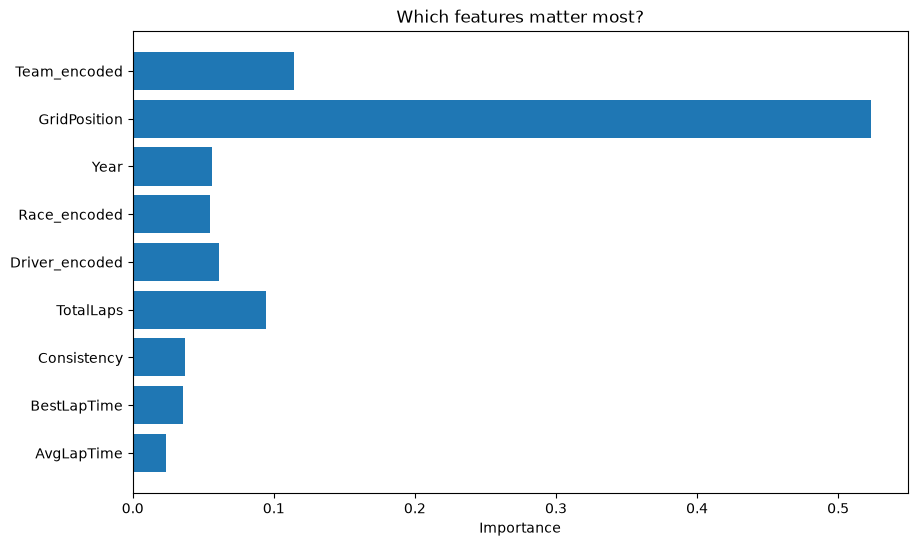

In [50]:
#check which features matter most
feature_names=['AvgLapTime','BestLapTime','Consistency','TotalLaps','Driver_encoded','Race_encoded','Year','GridPosition','Team_encoded']
importances=model2.feature_importances_
plt.figure(figsize=(10,6))
plt.barh(feature_names,importances)
plt.title('Which features matter most?')
plt.xlabel('Importance')
plt.show()


In [56]:
# Check for duplicates in results_df
print("Duplicates in results_df:")
print(results_df.duplicated(subset=['Driver', 'Year', 'Race']).sum())

# Check for duplicates in features
print("\nDuplicates in features:")
print(features.duplicated(subset=['Driver', 'Year', 'Race']).sum())

# Check how many rows match
common = features.merge(results_df, on=['Driver', 'Year', 'Race'], how='inner')
print(f"\nMatching rows: {len(common)}")

# Check a specific race to see if names match exactly
print("\nFeatures - Bahrain 2023:")
print(features[(features['Race']=='Bahrain Grand Prix') & (features['Year']==2023)]['Driver'].tolist())

print("\nResults - Bahrain 2023:")
print(results_df[(results_df['Race']=='Bahrain Grand Prix') & (results_df['Year']==2023)]['Driver'].tolist())

Duplicates in results_df:
0

Duplicates in features:
0

Matching rows: 903

Features - Bahrain 2023:
['ALB', 'ALO', 'BOT', 'DEV', 'GAS', 'HAM', 'HUL', 'LEC', 'MAG', 'NOR', 'OCO', 'PER', 'PIA', 'RUS', 'SAI', 'SAR', 'STR', 'TSU', 'VER', 'ZHO']

Results - Bahrain 2023:
[]


In [60]:
print(results_df['Year'].unique())
print(results_df.groupby('Year')['Race'].nunique())


[2020 2021 2022]
Year
2020    17
2021    22
2022     9
Name: Race, dtype: int64


In [ ]:
all_results_new=[]

for year in [2023,2024]:
    try:
        schedule=fastf1.get_event_schedule(year)
        for _,event in schedule.iterrows():
            try:
                if 'Test' in event['EventName'] or 'Pre-Season' in event['EventName']:
                    continue
                session=fastf1.get_session(year,event['EventName'],'R')
                session.load(telemetry=False,weather=False,messages=False)
                results=session.results[['Abbreviation','GridPosition','TeamName']]
                results=results.rename(columns={'Abbreviation':'Driver'})
                results['Year']=year
                results['Race']=event['EventName']
                all_results_new.append(results)
                print(f"Loaded {year} - {event['EventName']}")
            except Exception as e:
                print(f"Skipped {event['EventName']} {year} - {e}")
                continue
    except Exception as e:
        print(f"Skipped {year} - {e}")
        continue

print(f"Done! Got {len(all_results_new)} races")

In [ ]:
#combining old and new results
results_df_final=pd.concat([results_df,pd.concat(all_results_new,ignore_index=True)],ignore_index=True)
print(results_df_final['Year'].unique()) 
print(results_df_final.groupby('Year')['Race'].nunique())

[2020 2021 2022 2023 2024]
Year
2020    17
2021    22
2022     9
2023    22
2024    24
Name: Race, dtype: int64


In [ ]:
all_results_2022=[]

try:
    schedule=fastf1.get_event_schedule(2022)
    for _,event in schedule.iterrows():
        try:
            if 'Test' in event['EventName'] or 'Pre-Season' in event['EventName']:
                continue
            session=fastf1.get_session(2022,event['EventName'],'R')
            session.load(telemetry=False,weather=False,messages=False)
            results=session.results[['Abbreviation','GridPosition','TeamName']]
            results=results.rename(columns={'Abbreviation':'Driver'})
            results['Year']=2022
            results['Race']=event['EventName']
            all_results_2022.append(results)
            print(f"Loaded 2022 - {event['EventName']}")
        except Exception as e:
            print(f"Skipped {event['EventName']} - {e}")
            continue
except Exception as e:
    print(f"Skipped 2022 - {e}")

print(f"Done! Got {len(all_results_2022)} races for 2022")

In [ ]:
results_2022_df=pd.concat(all_results_2022,ignore_index=True)
results_2022_df['Year']=2022

#removing old incomplete 2022 data and replace with new as the old one had 9 races data only
results_df_final=results_df_final[results_df_final['Year']!=2022]
results_df_final=pd.concat([results_df_final,results_2022_df],ignore_index=True)

print(results_df_final.groupby('Year')['Race'].nunique())

Year
2020    17
2021    22
2022    13
2023    22
2024    24
Name: Race, dtype: int64


In [ ]:
#Clean results
results_df_final=results_df_final[~results_df_final['Race'].str.contains('Test|Pre-Season',case=False)]
results_df_final=results_df_final.dropna(subset=['GridPosition'])
results_df_final['GridPosition']=results_df_final['GridPosition'].astype(int)

#Merge
features_final=features.merge(results_df_final,on=['Driver','Year','Race'],how='inner')
print(f"Features before merge: {len(features)}")
print(f"Features after merge: {len(features_final)}")
features_final.head()

Features before merge: 2609
Features after merge: 1874


,Year,Race,Driver,AvgLapTime,BestLapTime,Consistency,TotalLaps,FinalPosition,Driver_encoded,Race_encoded,GridPosition,TeamName
0,2020,70th Anniversary Grand Prix,ALB,92.714212,89.477,4.292136,52.0,5,1,0,9,Red Bull Racing
1,2020,70th Anniversary Grand Prix,BOT,92.331231,89.765,3.918965,52.0,3,6,0,1,Mercedes
2,2020,70th Anniversary Grand Prix,GAS,93.319904,90.092,4.336579,52.0,11,11,0,7,AlphaTauri
3,2020,70th Anniversary Grand Prix,GIO,94.372686,91.826,4.033917,51.0,17,12,0,19,Alfa Romeo Racing
4,2020,70th Anniversary Grand Prix,GRO,94.258961,90.793,4.657381,51.0,16,13,0,13,Haas F1 Team


In [ ]:
le_driver_f=LabelEncoder()
le_race_f=LabelEncoder()
le_team_f=LabelEncoder()

features_final['Driver_encoded']=le_driver_f.fit_transform(features_final['Driver'])
features_final['Race_encoded']=le_race_f.fit_transform(features_final['Race'])
features_final['Team_encoded']=le_team_f.fit_transform(features_final['TeamName'])

X_f=features_final[['AvgLapTime','BestLapTime','Consistency','TotalLaps','Driver_encoded','Race_encoded','Year','GridPosition','Team_encoded']]
y_f=features_final['FinalPosition']

X_f_train,X_f_test,y_f_train,y_f_test=train_test_split(X_f,y_f,test_size=0.2,random_state=42)

model_f=XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=4,subsample=0.8,colsample_bytree=0.8,random_state=42)
model_f.fit(X_f_train,y_f_train)

y_f_pred=model_f.predict(X_f_test)
mae_f=mean_absolute_error(y_f_test,y_f_pred)
print(f"Final model MAE: {mae_f:.2f}")


Original MAE: 2.45
Final model MAE: 2.27
Improvement: 0.18 positions better!


In [ ]:
#getting Monaco 2024 data from features_final
monaco=features_final[(features_final['Race']=='Monaco Grand Prix') & (features_final['Year']==2024)].copy()
print(f"Drivers in Monaco 2024:{len(monaco)}")
monaco[['Driver','GridPosition','FinalPosition']]

Drivers in Monaco 2024: 16


,Driver,GridPosition,FinalPosition
1744,ALB,9,9
1745,ALO,14,11
1746,BOT,17,13
1747,GAS,10,10
1748,HAM,7,7
1749,LEC,1,1
1750,NOR,4,4
1751,PIA,2,2
1752,RIC,12,12
1753,RUS,5,5


In [ ]:
#Prepare monaco data for prediction
monaco_X=monaco[['AvgLapTime','BestLapTime','Consistency','TotalLaps','Driver_encoded','Race_encoded','Year','GridPosition','Team_encoded']]
monaco['PredictedPosition']=model_f.predict(monaco_X)
monaco['PredictedPosition']=monaco['PredictedPosition'].round().astype(int)
monaco_sorted=monaco[['Driver','GridPosition','PredictedPosition','FinalPosition']].sort_values('PredictedPosition')

print(monaco_sorted.to_string(index=False))

Driver  GridPosition  PredictedPosition  FinalPosition
   LEC             1                  2              1
   SAI             3                  3              3
   PIA             2                  4              2
   NOR             4                  4              4
   RUS             5                  5              5
   VER             6                  5              6
   HAM             7                  6              7
   ALB             9                  9              9
   GAS            10                 10             10
   TSU             8                 10              8
   RIC            12                 11             12
   ALO            14                 12             11
   STR            13                 12             14
   BOT            17                 15             13
   SAR            15                 15             15
   ZHO            18                 17             16


In [ ]:
monaco['PredictedPosition']=model_f.predict(monaco_X)

#ranking instead of round as positions were repeating so this guarantees unique positions
monaco['PredictedPosition']=monaco['PredictedPosition'].rank(method='first').astype(int)
monaco_sorted=monaco[['Driver','GridPosition','PredictedPosition','FinalPosition']].sort_values('PredictedPosition')
print(monaco_sorted.to_string(index=False))

Driver  GridPosition  PredictedPosition  FinalPosition
   LEC             1                  1              1
   SAI             3                  2              3
   PIA             2                  3              2
   NOR             4                  4              4
   VER             6                  5              6
   RUS             5                  6              5
   HAM             7                  7              7
   ALB             9                  8              9
   GAS            10                  9             10
   TSU             8                 10              8
   RIC            12                 11             12
   STR            13                 12             14
   ALO            14                 13             11
   SAR            15                 14             15
   BOT            17                 15             13
   ZHO            18                 16             16


In [ ]:
def predict_race(race_name,year):
    #Filter race from features_final
    race=features_final[
        (features_final['Race']==race_name) &
        (features_final['Year']==year)
    ].copy()
    
    if len(race)==0:
        print(f"No data found for {race_name} {year}")
        return
    
    #p[redict
    race_X=race[['AvgLapTime','BestLapTime','Consistency','TotalLaps','Driver_encoded','Race_encoded','Year','GridPosition','Team_encoded']]
    race['PredictedPosition']=model_f.predict(race_X)
    race['PredictedPosition']=race['PredictedPosition'].rank(method='first').astype(int)

    result=race[['Driver','GridPosition','PredictedPosition','FinalPosition']].sort_values('PredictedPosition')
    return result

In [ ]:
print(predict_race('British Grand Prix',2024))
print(predict_race('Bahrain Grand Prix',2023))

     Driver  GridPosition  PredictedPosition  FinalPosition
1546    VER             4                  1              2
1532    HAM             2                  2              1
1536    NOR             3                  3              3
1541    RUS             1                  4              4
1539    PIA             5                  5              4
1542    SAI             7                  6              5
1533    HUL             6                  7              6
1530    ALO            10                  8              8
1544    STR             8                  9              7
1529    ALB             9                 10              9
1534    LEC            11                 11             14
1538    PER            20                 12             17
1540    RIC            15                 13             13
1545    TSU            13                 14             10
1543    SAR            12                 15             11
1537    OCO            18               

In [72]:
import joblib

joblib.dump(model_f,'model.pkl')
joblib.dump(le_driver_f,'le_driver.pkl')
joblib.dump(le_race_f,'le_race.pkl')
joblib.dump(le_team_f,'le_team.pkl')
features_final.to_csv('data/f1_features_final.csv',index=False)

print("saved")

saved
